In [1]:
import pandas as pd
import os
import numpy as np
import os
pd.options.display.float_format = '{:.2f}'.format
# Get the current working directory
current_directory = os.getcwd()
print(current_directory)
# Parameter windowing
input_width = 48
label_width = 48
shift = label_width
total_window_size = input_width + shift
OUT_STEPS = label_width
# Definisikan irisan untuk input dan label
input_slice = slice(0, input_width)
label_start = total_window_size - label_width
labels_slice = slice(label_start, None)

def import_data(pathload, hari_khusus_saja=False):
    df_awal=pd.read_excel(pathload)
    #DROP KOLOM SUHU
    df_awal.drop(columns=['Keterangan', 'Keterangan.1'], inplace=True)
    df_awal.dropna(subset=['Beban'], inplace=True)
    df_awal['Hari_Khus'] = df_awal['Hari_Khus'].replace(13, 23)
    if hari_khusus_saja==True:
        return df_awal[df_awal['Hari_Khus']!=0].copy()
    else:
        return df_awal.copy()
    
    
def datetime_kolom(data, jumlah_hari, kelipatan_hari):
    df=data.copy()
    df['Date']=pd.to_datetime(df['Date'], format="%Y-%m-%d %H:%M:%S", dayfirst=True) #year-month-day(tanggal bukan hari)  H= hours, M=minutes, S= sekon 
    df['Tanggal']=df['Date'].dt.day
    df['Bulan']=df['Date'].dt.month
    df['Tahun']=df['Date'].dt.year
    df['Jam']=df['Date'].dt.hour
    df['Menit']=df['Date'].dt.minute
    
    df['Jam']=df['Jam']+df['Menit']/60 # agar setiap 30 menit menjadi 0.5 jam (contoh jam 13:30 menjadi 13.5)
    df.drop(columns=['Menit'], inplace=True)

    #1 hari = 48 (karena 30 menit), 1 bulan = 30 hari, 1 tahun =12 bulan
    mod_data= df['Beban'].count() % 48
    smpl_dta=df['Date'].count()-df['Beban'].count()+mod_data+(48*jumlah_hari*kelipatan_hari)
    df=df[-smpl_dta:]
    return df.copy()


def make_windows(data_x,data_y, total_window_size, input_slice, labels_slice):
    x = []
    y = []
    for i in range(len(data_x) - total_window_size + 1):
        window_x = data_x[i:i+total_window_size]
        x.append(window_x[input_slice])

    for i in range(len(data_y) - total_window_size + 1):
        window_y= data_y[i:i+total_window_size]
        y.append(window_y[labels_slice])

    return np.array(x), np.array(y)
def sin_cos_time(data):
    df= data.copy()
    df['Jam_sin'] = np.sin(df['Jam'] * (2 * np.pi / 24))
    df['Jam_cos'] = np.cos(df['Jam'] * (2 * np.pi / 24))
    df['Hari_sin'] = np.sin((df['Hari']-1) * (2 * np.pi / 7))
    df['Hari_cos'] = np.cos((df['Hari']-1) * (2 * np.pi / 7))
    df['Tanggal_sin'] = np.sin((df['Tanggal']-1) * (2 * np.pi / 30))
    df['Tanggal_cos'] = np.cos((df['Tanggal']-1) * (2 * np.pi / 30))
    df['Bulan_sin'] = np.sin((df['Bulan']-1) * (2 * np.pi / 12))
    df['Bulan_cos'] = np.cos((df['Bulan']-1) * (2 * np.pi / 12))
    
    #df['Hari_Khus_sin'] = np.sin((df['Hari_Khus']) * (2 * np.pi / 31))
    #df['Hari_Khus_cos']= np.cos((df['Hari_Khus']) * (2 * np.pi / 31))

    # mean_beban_per_jenis = df.groupby('Hari_Khus')['Beban'].mean()
    # # Hitung rata-rata beban global (keseluruhan data)
    # global_mean = df['Beban'].mean()

    # # Buat dictionary map: {Kode_Hari: Rasio_Impact}
    # # Contoh: Jika Hari 8 ratanya 17000 dan Global 25000, maka skornya 0.68 (turun 32%)
    # impact_map = mean_beban_per_jenis / global_mean

    # # Map ke kolom baru. Hari normal (0) akan memiliki nilai mendekati 1.0
    # df['Holiday_Impact'] = df['Hari_Khus'].map(impact_map)

    # # (Opsional) Jika ada kode baru di masa depan yang tidak ada di training, isi dengan 1.0 (Normal)
    # df['Holiday_Impact'] = df['Holiday_Impact'].fillna(1.0)

    # --- IMPLEMENTASI SMOOTHED MEAN ENCODING ---

    # 1. Hitung Rata-rata Global (Baseline)
    global_mean = df['Beban'].mean()

    # 2. Hitung Statistik per 'Hari_Khus' (Rata-rata DAN Jumlah Sampel)
    # Kita perlu tahu 'count' (berapa kali hari itu muncul)
    agregat = df.groupby('Hari_Khus')['Beban'].agg(['mean', 'count'])
    print(agregat  )
    # 3. Tentukan Faktor Smoothing 'm' (Weight)
    # Nilai m menentukan seberapa kuat kita "percaya" pada rata-rata global.
    # m = 10 adalah standar yang aman. Artinya: jika sampel < 10, nilai akan digeser mendekati global mean.
    m = 10

    # 4. Rumus Smoothed Mean
    # (n * category_mean + m * global_mean) / (n + m)
    smoothed_values = (
        (agregat['count'] * agregat['mean']) + (m * global_mean)
    ) / (agregat['count'] + m)

    # 5. Buat Dictionary Map: Rasio Smoothed Mean terhadap Global Mean
    impact_map = smoothed_values / global_mean

    # 6. Map ke kolom baru di DataFrame
    df['Holiday_Impact'] = df['Hari_Khus'].map(impact_map)

    # 7. Isi nilai yang kosong (jika ada kode baru di masa depan) dengan 1.0 (Normal)
    df['Holiday_Impact'] = df['Holiday_Impact'].fillna(1.0)
    return df.copy()
    

d:\JAMALI FORECASTING\1_pre


# DF AWAL

In [2]:
df_awal                         =   import_data(pathload='D:\\JAMALI FORECASTING\\Data_2025_10.xlsx', hari_khusus_saja=False)

In [3]:
df_awal

,Date,Bandung,Bekasi,Bogor,Cikarang,Cirebon,Denpasar,Gresik,Jakarta,Jember,...,Semarang,Sidoarjo,Surabaya,Surakarta,Tangerang,Tegal,Yogyakarta,Hari,Hari_Khus,Beban
0,2022-01-01 00:30:00,19.90,24.80,23.70,24.50,24.55,23.65,25.40,24.95,23.75,...,24.80,24.50,24.80,22.80,25.15,25.15,22.70,6,2,18402.00
1,2022-01-01 01:00:00,19.90,24.50,23.50,24.20,24.40,23.50,25.20,24.80,23.60,...,25.70,24.40,24.50,22.60,25.00,25.10,22.50,6,2,18214.00
2,2022-01-01 01:30:00,20.00,24.40,23.30,24.05,24.05,23.75,24.90,24.70,23.55,...,25.05,24.15,24.20,22.60,24.90,25.00,22.45,6,2,17974.00
3,2022-01-01 02:00:00,20.10,24.30,23.10,23.90,23.70,24.00,24.60,24.60,23.50,...,24.40,23.90,23.90,22.60,24.80,24.90,22.40,6,2,17729.00
4,2022-01-01 02:30:00,19.50,24.15,22.90,23.80,24.35,24.15,24.55,24.55,23.35,...,24.10,23.95,24.00,22.60,24.80,24.65,22.20,6,2,17532.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67123,2025-10-30 10:00:00,25.90,30.50,26.90,30.00,29.70,28.10,29.50,30.10,30.30,...,29.60,29.70,29.00,28.90,29.90,31.10,27.10,4,0,30957.80
67124,2025-10-30 10:30:00,26.50,31.15,27.40,30.55,30.15,28.35,29.70,30.75,30.70,...,29.70,30.25,29.45,29.10,30.60,31.65,27.20,4,0,30580.79
67125,2025-10-30 11:00:00,27.10,31.80,27.90,31.10,30.60,28.60,29.90,31.40,31.10,...,29.80,30.80,29.90,29.30,31.30,32.20,27.30,4,0,31497.36
67126,2025-10-30 11:30:00,27.35,32.15,28.15,31.65,30.95,28.70,30.05,31.85,31.30,...,29.95,31.25,30.10,29.45,31.75,32.65,27.35,4,0,31337.59


In [4]:
print(" hari khusus: ", sorted(df_awal['Hari_Khus'].unique()))
print("nama kolom: ", df_awal.columns.tolist())
# Korelasi untuk kolom numerik terhadap 'Beban'
print(" korelasi pearson kolom numerik terhadap 'Beban': ")
print(df_awal.select_dtypes(include='number').corr()['Beban'].sort_values(ascending=False))

 hari khusus:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 23, 25, 26, 27, 28, 29, 30, 31]
nama kolom:  ['Date', 'Bandung', 'Bekasi', 'Bogor', 'Cikarang', 'Cirebon', 'Denpasar', 'Gresik', 'Jakarta', 'Jember', 'Karawang', 'Malang', 'Pasuruan', 'Pekalongan', 'Semarang', 'Sidoarjo', 'Surabaya', 'Surakarta', 'Tangerang', 'Tegal', 'Yogyakarta', 'Hari', 'Hari_Khus', 'Beban']
 korelasi pearson kolom numerik terhadap 'Beban': 
Beban         1.00
Bekasi        0.54
Surabaya      0.54
Tangerang     0.54
Jakarta       0.53
Pekalongan    0.53
Cikarang      0.53
Sidoarjo      0.52
Tegal         0.52
Gresik        0.52
Semarang      0.52
Karawang      0.51
Bandung       0.51
Surakarta     0.50
Pasuruan      0.50
Cirebon       0.50
Yogyakarta    0.47
Bogor         0.47
Jember        0.47
Denpasar      0.43
Malang        0.34
Hari         -0.29
Hari_Khus    -0.31
Name: Beban, dtype: float64


In [5]:
df_awal.describe()

,Bandung,Bekasi,Bogor,Cikarang,Cirebon,Denpasar,Gresik,Jakarta,Jember,Karawang,...,Semarang,Sidoarjo,Surabaya,Surakarta,Tangerang,Tegal,Yogyakarta,Hari,Hari_Khus,Beban
count,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,...,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00
mean,23.19,27.39,25.46,27.27,27.65,26.70,27.89,27.31,26.23,27.39,...,27.82,27.49,27.95,26.80,27.02,27.12,25.84,4.00,1.30,25439.13
std,3.11,2.95,2.89,2.98,2.97,1.97,2.37,2.86,2.87,2.96,...,2.68,2.69,2.47,3.12,2.83,2.87,2.67,2.00,4.95,3161.24
min,13.70,20.30,17.70,19.80,19.30,19.90,20.90,20.00,15.00,21.00,...,21.00,18.80,19.70,19.50,19.10,19.80,16.70,1.00,0.00,13475.00
25%,20.90,25.10,23.20,24.95,25.30,25.30,26.10,25.00,24.10,25.10,...,25.85,25.40,26.05,24.40,24.70,24.85,23.90,2.00,0.00,23153.00
50%,22.80,26.80,24.80,26.55,27.00,26.60,27.45,26.70,25.70,26.65,...,27.30,27.15,27.70,26.00,26.50,26.50,25.40,4.00,0.00,25444.64
75%,25.40,29.50,27.50,29.40,29.70,28.05,29.50,29.50,28.35,29.50,...,29.30,29.45,29.65,28.90,29.20,29.30,27.80,6.00,0.00,27759.06
max,33.40,38.80,37.00,38.80,38.10,35.30,36.60,36.80,35.90,38.50,...,38.20,38.40,37.40,38.40,36.60,37.10,35.40,7.00,31.00,34104.89


# DF 1

In [6]:
df_1=datetime_kolom(data=df_awal, jumlah_hari=365*4, kelipatan_hari=1)
df_1 =df_1[['Date','Bulan','Tanggal','Hari', 'Jam','Beban', "Hari_Khus"]].copy()
df_1

,Date,Bulan,Tanggal,Hari,Jam,Beban,Hari_Khus
0,2022-01-01 00:30:00,1,1,6,0.50,18402.00,2
1,2022-01-01 01:00:00,1,1,6,1.00,18214.00,2
2,2022-01-01 01:30:00,1,1,6,1.50,17974.00,2
3,2022-01-01 02:00:00,1,1,6,2.00,17729.00,2
4,2022-01-01 02:30:00,1,1,6,2.50,17532.00,2
...,...,...,...,...,...,...,...
67123,2025-10-30 10:00:00,10,30,4,10.00,30957.80,0
67124,2025-10-30 10:30:00,10,30,4,10.50,30580.79,0
67125,2025-10-30 11:00:00,10,30,4,11.00,31497.36,0
67126,2025-10-30 11:30:00,10,30,4,11.50,31337.59,0


In [7]:
print("korelasi pearson datetime terhadap 'Beban': ")
print(df_1.select_dtypes(include='number').corr()['Beban'].sort_values(ascending=False))

korelasi pearson datetime terhadap 'Beban': 
Beban        1.00
Jam          0.44
Bulan        0.16
Tanggal      0.03
Hari        -0.29
Hari_Khus   -0.31
Name: Beban, dtype: float64


# DF2

In [8]:
df_2= sin_cos_time(df_1)
df_2.drop(columns=['Bulan', 'Tanggal', "Hari", "Jam", "Hari_Khus"], inplace=True)
print(df_2.shape)
df_2.set_index('Date', inplace=True)
df_2.index = pd.to_datetime(df_2.index)
df_2= df_2.astype('float32').copy()
df_2.tail()

              mean  count
Hari_Khus                
0         25744.92  57337
1         25636.28   4848
2         19068.93    191
3         21467.38    191
4         21852.83    192
5         22421.20     96
6         24086.00    144
7         22986.32    144
8         17339.02    191
9         17458.76    192
10        23894.40    144
11        24311.79    192
12        23410.52    144
14        22580.72    192
15        21462.51    192
16        23081.36    191
17        21656.99    144
18        25406.20    720
19        22251.73     96
23        20453.51    192
25        21630.82    192
26        19523.56    192
27        18306.65    194
28        18015.23    192
29        18620.49    192
30        20162.16    193
31        23027.16    240
(67128, 11)


,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Tanggal_sin,Tanggal_cos,Bulan_sin,Bulan_cos,Holiday_Impact
Date,,,,,,,,,,
2025-10-30 10:00:00,30957.80,0.50,-0.87,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01
2025-10-30 10:30:00,30580.79,0.38,-0.92,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01
2025-10-30 11:00:00,31497.36,0.26,-0.97,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01
2025-10-30 11:30:00,31337.59,0.13,-0.99,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01
2025-10-30 12:00:00,20014.88,0.00,-1.00,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01


In [9]:
df_2

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Tanggal_sin,Tanggal_cos,Bulan_sin,Bulan_cos,Holiday_Impact
Date,,,,,,,,,,
2022-01-01 00:30:00,18402.00,0.13,0.99,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76
2022-01-01 01:00:00,18214.00,0.26,0.97,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76
2022-01-01 01:30:00,17974.00,0.38,0.92,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76
2022-01-01 02:00:00,17729.00,0.50,0.87,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76
2022-01-01 02:30:00,17532.00,0.61,0.79,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76
...,...,...,...,...,...,...,...,...,...,...
2025-10-30 10:00:00,30957.80,0.50,-0.87,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01
2025-10-30 10:30:00,30580.79,0.38,-0.92,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01
2025-10-30 11:00:00,31497.36,0.26,-0.97,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01


In [10]:
print("korelasi pearson datetime terhadap 'Beban': ")
print(df_2.select_dtypes(include='number').corr()['Beban'].sort_values(ascending=False))
df_2.describe()

korelasi pearson datetime terhadap 'Beban': 
Beban             1.00
Holiday_Impact    0.40
Hari_sin          0.31
Tanggal_sin      -0.02
Tanggal_cos      -0.07
Bulan_cos        -0.10
Hari_cos         -0.15
Bulan_sin        -0.17
Jam_cos          -0.31
Jam_sin          -0.47
Name: Beban, dtype: float64


,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Tanggal_sin,Tanggal_cos,Bulan_sin,Bulan_cos,Holiday_Impact
count,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00
mean,25439.13,0.00,-0.00,0.00,0.00,0.00,0.01,0.03,-0.03,1.00
std,3161.22,0.71,0.71,0.71,0.71,0.70,0.71,0.71,0.71,0.05
min,13475.00,-1.00,-1.00,-0.97,-0.90,-0.99,-1.00,-1.00,-1.00,0.70
25%,23153.00,-0.71,-0.71,-0.78,-0.90,-0.74,-0.67,-0.50,-0.87,1.01
50%,25444.64,0.00,-0.00,0.00,-0.22,0.00,0.10,0.00,-0.00,1.01
75%,27759.07,0.71,0.71,0.78,0.62,0.74,0.67,0.87,0.50,1.01
max,34104.89,1.00,1.00,0.97,1.00,0.99,1.00,1.00,1.00,1.01


In [11]:
np.sin(1* (6 * np.pi / 7))

0.43388373911755823

# df3

In [12]:
df_3_awal= df_awal.copy()
df_3_awal.set_index('Date', inplace=True)
df_3_awal.index = pd.to_datetime(df_3_awal.index)

df_3= df_2.copy()
df_3.dtypes

Beban             float32
Jam_sin           float32
Jam_cos           float32
Hari_sin          float32
Hari_cos          float32
Tanggal_sin       float32
Tanggal_cos       float32
Bulan_sin         float32
Bulan_cos         float32
Holiday_Impact    float32
dtype: object

In [13]:
kolom_yang_belum_ada = df_3_awal.columns.difference(df_3.columns).difference(['Hari', 'Hari_Khus'])
kolom_yang_belum_ada

Index(['Bandung', 'Bekasi', 'Bogor', 'Cikarang', 'Cirebon', 'Denpasar',
       'Gresik', 'Jakarta', 'Jember', 'Karawang', 'Malang', 'Pasuruan',
       'Pekalongan', 'Semarang', 'Sidoarjo', 'Surabaya', 'Surakarta',
       'Tangerang', 'Tegal', 'Yogyakarta'],
      dtype='object')

In [14]:
df_3 = df_3.join(df_3_awal[kolom_yang_belum_ada])
df_3 = df_3.copy()
cols = df_3.select_dtypes(include=['number']).columns
# 2. Convert them all to float32
df_3[cols] = df_3[cols].astype('float32')
df_3.dtypes

Beban             float32
Jam_sin           float32
Jam_cos           float32
Hari_sin          float32
Hari_cos          float32
Tanggal_sin       float32
Tanggal_cos       float32
Bulan_sin         float32
Bulan_cos         float32
Holiday_Impact    float32
Bandung           float32
Bekasi            float32
Bogor             float32
Cikarang          float32
Cirebon           float32
Denpasar          float32
Gresik            float32
Jakarta           float32
Jember            float32
Karawang          float32
Malang            float32
Pasuruan          float32
Pekalongan        float32
Semarang          float32
Sidoarjo          float32
Surabaya          float32
Surakarta         float32
Tangerang         float32
Tegal             float32
Yogyakarta        float32
dtype: object

In [15]:
df_3

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Tanggal_sin,Tanggal_cos,Bulan_sin,Bulan_cos,Holiday_Impact,...,Malang,Pasuruan,Pekalongan,Semarang,Sidoarjo,Surabaya,Surakarta,Tangerang,Tegal,Yogyakarta
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:30:00,18402.00,0.13,0.99,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,...,21.70,23.90,24.70,24.80,24.50,24.80,22.80,25.15,25.15,22.70
2022-01-01 01:00:00,18214.00,0.26,0.97,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,...,22.10,23.70,24.70,25.70,24.40,24.50,22.60,25.00,25.10,22.50
2022-01-01 01:30:00,17974.00,0.38,0.92,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,...,21.95,23.55,24.65,25.05,24.15,24.20,22.60,24.90,25.00,22.45
2022-01-01 02:00:00,17729.00,0.50,0.87,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,...,21.80,23.40,24.60,24.40,23.90,23.90,22.60,24.80,24.90,22.40
2022-01-01 02:30:00,17532.00,0.61,0.79,-0.97,-0.22,0.00,1.00,0.00,1.00,0.76,...,21.40,23.40,24.15,24.10,23.95,24.00,22.60,24.80,24.65,22.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-30 10:00:00,30957.80,0.50,-0.87,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01,...,25.30,29.80,30.70,29.60,29.70,29.00,28.90,29.90,31.10,27.10
2025-10-30 10:30:00,30580.79,0.38,-0.92,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01,...,25.25,30.30,31.15,29.70,30.25,29.45,29.10,30.60,31.65,27.20
2025-10-30 11:00:00,31497.36,0.26,-0.97,0.43,-0.90,-0.21,0.98,-1.00,-0.00,1.01,...,25.20,30.80,31.60,29.80,30.80,29.90,29.30,31.30,32.20,27.30


In [16]:
df_3.corr()['Beban'].sort_values(ascending=False)

Beban             1.00
Bekasi            0.54
Surabaya          0.54
Tangerang         0.54
Jakarta           0.53
Pekalongan        0.53
Cikarang          0.53
Sidoarjo          0.52
Tegal             0.52
Gresik            0.52
Semarang          0.52
Karawang          0.51
Bandung           0.51
Surakarta         0.50
Pasuruan          0.50
Cirebon           0.50
Yogyakarta        0.47
Bogor             0.47
Jember            0.47
Denpasar          0.43
Holiday_Impact    0.40
Malang            0.34
Hari_sin          0.31
Tanggal_sin      -0.02
Tanggal_cos      -0.07
Bulan_cos        -0.10
Hari_cos         -0.15
Bulan_sin        -0.17
Jam_cos          -0.31
Jam_sin          -0.47
Name: Beban, dtype: float64

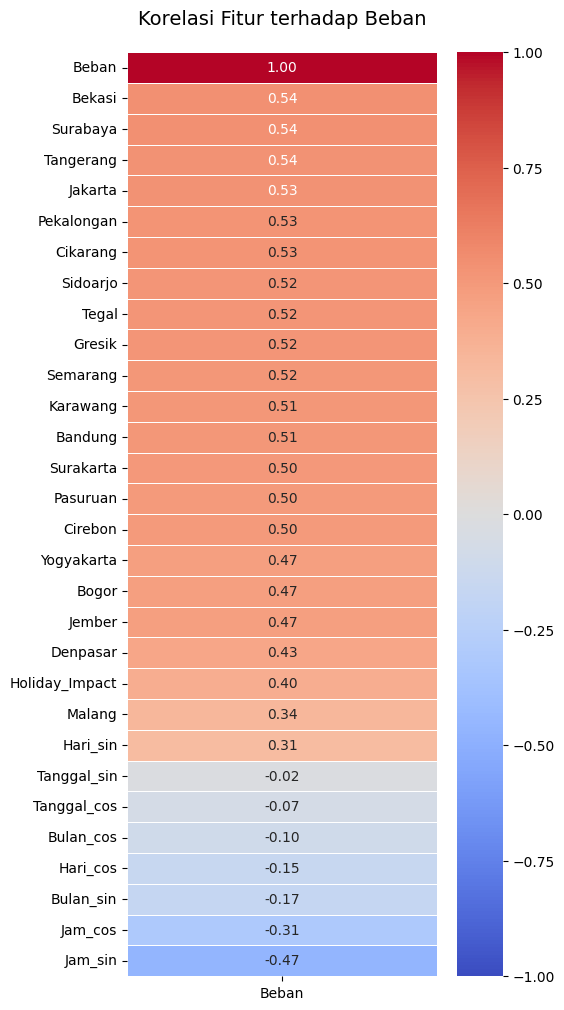

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung korelasi
correlation = df_3.corr()

# --- OPSI 1: Heatmap Fokus ke 'Beban' (Paling Direkomendasikan) ---
plt.figure(figsize=(5, 12)) # Ukuran ramping memanjang ke bawah

# Kita ambil hanya kolom 'Beban', lalu urutkan dari terbesar
target_corr = correlation[['Beban']].sort_values(by='Beban', ascending=False)

# Plot Heatmap
sns.heatmap(target_corr, 
            annot=True,    # Tampilkan angkanya
            cmap='coolwarm', # Warna: Merah (Positif), Biru (Negatif)
            vmin=-1, vmax=1, # Batas warna dari -1 hingga 1
            fmt='.2f',     # Format 2 angka di belakang koma
            linewidths=0.5)

plt.title("Korelasi Fitur terhadap Beban", fontsize=14, pad=20)
plt.show()

# # --- OPSI 2: Heatmap Lengkap (Semua vs Semua) ---
# plt.figure(figsize=(16, 14)) # Ukuran besar agar tulisan terbaca

# mask = np.triu(np.ones_like(correlation, dtype=bool)) # (Opsional) Hapus segitiga atas agar tidak dobel

# sns.heatmap(correlation, 
#             mask=mask,     # Gunakan mask jika ingin segitiga saja
#             annot=True, 
#             cmap='coolwarm', 
#             center=0,      # Warna putih di angka 0
#             fmt='.2f', 
#             square=True, 
#             linewidths=0.5)

# plt.title("Matriks Korelasi Pearson Lengkap", fontsize=16)
# plt.show()

In [18]:
excel_desc= df_3.describe()
display(excel_desc)
excel_desc.to_excel('descriptive_statistics_df3.xlsx')

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Tanggal_sin,Tanggal_cos,Bulan_sin,Bulan_cos,Holiday_Impact,...,Malang,Pasuruan,Pekalongan,Semarang,Sidoarjo,Surabaya,Surakarta,Tangerang,Tegal,Yogyakarta
count,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,...,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00,67128.00
mean,25439.13,0.00,-0.00,0.00,0.00,0.00,0.01,0.03,-0.03,1.00,...,23.84,27.19,27.16,27.82,27.49,27.95,26.80,27.02,27.12,25.84
std,3161.22,0.71,0.71,0.71,0.71,0.70,0.71,0.71,0.71,0.05,...,2.83,3.03,2.84,2.68,2.69,2.47,3.12,2.83,2.87,2.67
min,13475.00,-1.00,-1.00,-0.97,-0.90,-0.99,-1.00,-1.00,-1.00,0.70,...,13.60,19.00,18.90,21.00,18.80,19.70,19.50,19.10,19.80,16.70
25%,23153.00,-0.71,-0.71,-0.78,-0.90,-0.74,-0.67,-0.50,-0.87,1.01,...,21.95,24.75,24.90,25.85,25.40,26.05,24.40,24.70,24.85,23.90
50%,25444.64,0.00,-0.00,0.00,-0.22,0.00,0.10,0.00,-0.00,1.01,...,23.30,26.60,26.70,27.30,27.15,27.70,26.00,26.50,26.50,25.40
75%,27759.07,0.71,0.71,0.78,0.62,0.74,0.67,0.87,0.50,1.01,...,25.80,29.65,29.40,29.30,29.45,29.65,28.90,29.20,29.30,27.80
max,34104.89,1.00,1.00,0.97,1.00,0.99,1.00,1.00,1.00,1.01,...,34.20,36.80,36.20,38.20,38.40,37.40,38.40,36.60,37.10,35.40


In [19]:
df_3.to_excel('data_df3.xlsx')

In [20]:

mean_load_per_holiday = df_1.groupby('Hari_Khus')['Beban'].mean()
mean_load_per_holiday

Hari_Khus
0    25744.92
1    25636.28
2    19068.93
3    21467.38
4    21852.83
5    22421.20
6    24086.00
7    22986.32
8    17339.02
9    17458.76
10   23894.40
11   24311.79
12   23410.52
14   22580.72
15   21462.51
16   23081.36
17   21656.99
18   25406.20
19   22251.73
23   20453.51
25   21630.82
26   19523.56
27   18306.65
28   18015.23
29   18620.49
30   20162.16
31   23027.16
Name: Beban, dtype: float64

In [21]:
df_dummy= df_1.copy()
# 1. Hitung rata-rata beban keseluruhan (baseline)
global_mean = df_dummy['Beban'].mean()

# 2. Ubah rata-rata per hari khusus menjadi Impact Score (Rasio)
# mean_load_per_holiday adalah Series yang ada di foto Anda
holiday_impact_map = mean_load_per_holiday / global_mean

# 3. Map kembali ke dataframe utama df_1
df_dummy['Holiday_Impact'] = df_dummy['Hari_Khus'].map(holiday_impact_map)

# 4. Isi hari-hari yang BUKAN hari khusus dengan angka 1
# (Artinya tidak ada kenaikan/penurunan beban karena libur)
df_dummy['Holiday_Impact'] = df_dummy ['Holiday_Impact'].fillna(1)
df_dummy['Date'] = pd.to_datetime(df_dummy['Date'])

# 2. Ambil tahun dari kolom 'Date' menggunakan .dt accessor
df_dummy['tahun'] = df_dummy['Date'].dt.year

In [22]:
df_dummy[(df_dummy['Hari_Khus']==2) & (df_dummy['tahun']==2022)]

,Date,Bulan,Tanggal,Hari,Jam,Beban,Hari_Khus,Holiday_Impact,tahun
0,2022-01-01 00:30:00,1,1,6,0.50,18402.00,2,0.75,2022
1,2022-01-01 01:00:00,1,1,6,1.00,18214.00,2,0.75,2022
2,2022-01-01 01:30:00,1,1,6,1.50,17974.00,2,0.75,2022
3,2022-01-01 02:00:00,1,1,6,2.00,17729.00,2,0.75,2022
4,2022-01-01 02:30:00,1,1,6,2.50,17532.00,2,0.75,2022
5,2022-01-01 03:00:00,1,1,6,3.00,17328.00,2,0.75,2022
6,2022-01-01 03:30:00,1,1,6,3.50,17269.00,2,0.75,2022
7,2022-01-01 04:00:00,1,1,6,4.00,17313.00,2,0.75,2022
8,2022-01-01 04:30:00,1,1,6,4.50,17564.00,2,0.75,2022
9,2022-01-01 05:00:00,1,1,6,5.00,17735.00,2,0.75,2022


In [23]:
holiday_impact_map

Hari_Khus
0    1.01
1    1.01
2    0.75
3    0.84
4    0.86
5    0.88
6    0.95
7    0.90
8    0.68
9    0.69
10   0.94
11   0.96
12   0.92
14   0.89
15   0.84
16   0.91
17   0.85
18   1.00
19   0.87
23   0.80
25   0.85
26   0.77
27   0.72
28   0.71
29   0.73
30   0.79
31   0.91
Name: Beban, dtype: float64

In [24]:
df_dummy.corr()['Beban'].sort_values(ascending=False)

Beban             1.00
Jam               0.44
Date              0.41
Holiday_Impact    0.40
tahun             0.37
Bulan             0.16
Tanggal           0.03
Hari             -0.29
Hari_Khus        -0.31
Name: Beban, dtype: float64

# FFT

In [25]:
df_1

,Date,Bulan,Tanggal,Hari,Jam,Beban,Hari_Khus
0,2022-01-01 00:30:00,1,1,6,0.50,18402.00,2
1,2022-01-01 01:00:00,1,1,6,1.00,18214.00,2
2,2022-01-01 01:30:00,1,1,6,1.50,17974.00,2
3,2022-01-01 02:00:00,1,1,6,2.00,17729.00,2
4,2022-01-01 02:30:00,1,1,6,2.50,17532.00,2
...,...,...,...,...,...,...,...
67123,2025-10-30 10:00:00,10,30,4,10.00,30957.80,0
67124,2025-10-30 10:30:00,10,30,4,10.50,30580.79,0
67125,2025-10-30 11:00:00,10,30,4,11.00,31497.36,0
67126,2025-10-30 11:30:00,10,30,4,11.50,31337.59,0


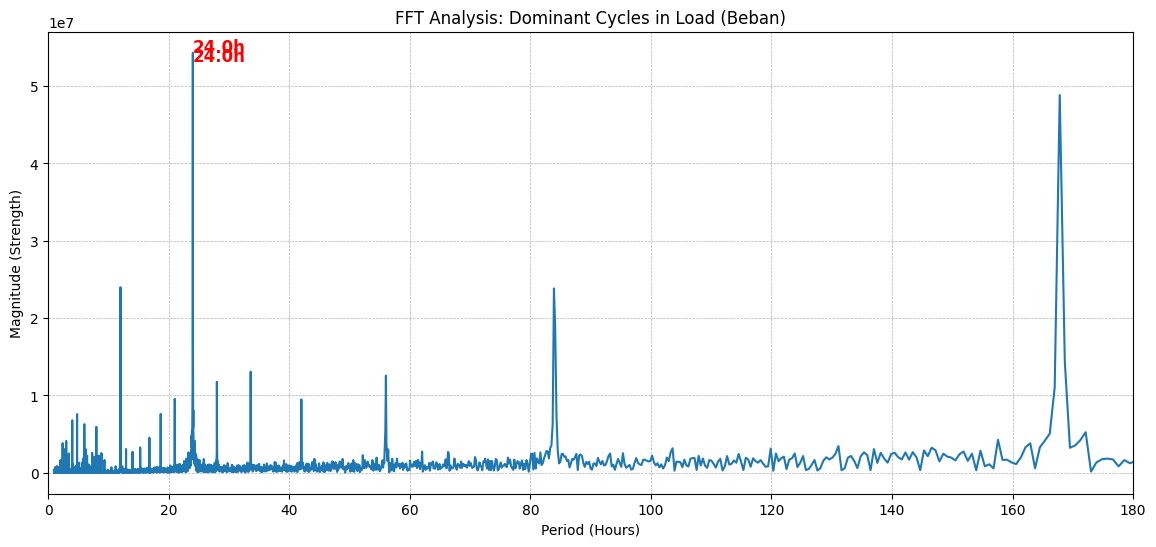

--- Top Detected Cycles ---
Cycle: Every 24.01 Hours (Strength: 54320950)
Cycle: Every 23.99 Hours (Strength: 53155446)
Cycle: Every 33564.00 Hours (Strength: 50730015)
Cycle: Every 167.82 Hours (Strength: 48845180)
Cycle: Every 8391.00 Hours (Strength: 28628813)


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
# IMPORTANT: Your data is every 30 minutes, so interval is 0.5 hours
sampling_interval = 0.5 

# --- 2. PREPARE DATA ---
# Take the 'Beban' column and remove empty values (NaN)
data = df_1['Beban'].dropna().values
n = len(data)

# Subtract the Mean (Center the data)
# This removes the "DC Component" (the huge spike at 0 Hz) so you can see the cycles.
data_centered = data - np.mean(data)

# --- 3. COMPUTE FFT ---
fft_values = np.fft.fft(data_centered)
frequencies = np.fft.fftfreq(n, d=sampling_interval)

# --- 4. FILTER POSITIVE FREQUENCIES ---
# FFT produces mirror results, we only need the positive half
mask = frequencies > 0
freqs = frequencies[mask]
magnitudes = np.abs(fft_values[mask])

# Convert Frequency (1/hour) to Period (Hours)
periods = 1 / freqs

# --- 5. VISUALIZATION ---
plt.figure(figsize=(14, 6))

# Plot Magnitude vs Period
plt.plot(periods, magnitudes)

# LIMIT THE VIEW: Focus on cycles between 0 and 200 hours (Daily/Weekly)
plt.xlim(0, 180) 
plt.title("FFT Analysis: Dominant Cycles in Load (Beban)")
plt.xlabel("Period (Hours)")
plt.ylabel("Magnitude (Strength)")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Annotate the Top 3 Peaks automatically
sorted_indices = np.argsort(magnitudes)[::-1] # Sort largest to smallest
for i in sorted_indices[:3]:
    p = periods[i]
    m = magnitudes[i]
    # Only label if it's within our zoom range (0-180h) to avoid clutter
    if 0 < p < 180:
        plt.text(p, m, f'{p:.1f}h', fontsize=12, fontweight='bold', color='red', ha='left')

plt.show()

# --- 6. PRINT TEXT REPORT ---
print("--- Top Detected Cycles ---")
for i in sorted_indices[:5]:
    print(f"Cycle: Every {periods[i]:.2f} Hours (Strength: {magnitudes[i]:.0f})")